### <u><B> *DBSCAN CLUSTERING*</B></U>

DBSCAN = Density Based Spatial Clustering of Application with Noise

DBSCAN groups data points based on how densely packed they are , instead of distance to a centroid

Why DBSCAN exist:

k-means struggles when :

- Clusters are non-spherical
- no.of clusters is unknown
- there are outliers

DBSCAN was designed to fix exactly these

DBSCAN works on the 2 parametrs and 3 types of points

parameters:

- eps (ε) - Radius
- min_samples - minimum points

types of points:

- Core point
- Border point
- Noise point

<img src="Visualization-of-DBSCAN-clustering-algorithm.png" width=400/>

##### DBSCAN Algorithm

Given parameters:

- $\varepsilon$ : neighborhood radius  
- $\text{minPts}$ : minimum number of points to form a dense region  

---

*Step 1:*  
Identify each point as **core point**, **border point**, or **noise point**.

*Step 2:*  
For each unclustered core point:


*Step 2a:*  
Create a new cluster.

*Step 2b:*  
Add all points that are unclustered and density-connected to the current point into this cluster.

*Step 3:* 
For each unclustered border point, assign it to the cluster of the nearest core point.

*Step 4:*  
Leave all remaining points as noise.


In [1]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X= np.array([[1,2],[2,2],[2,3],[8,7],[8,8],[25,80]])

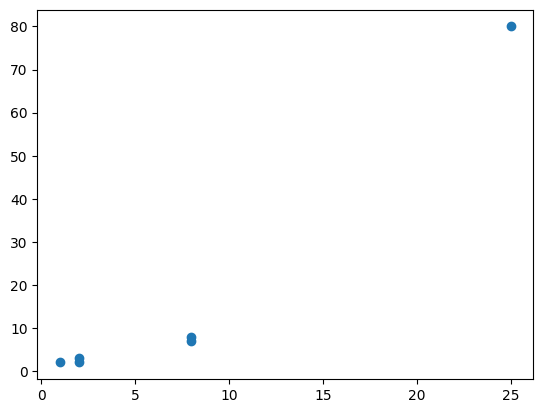

In [5]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [9]:
db= DBSCAN(eps=3,min_samples=2)
db.fit(X)
db.labels_

array([ 0,  0,  0,  1,  1, -1])

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import numpy as np

In [12]:
X,_ =make_circles(n_samples=500,factor=.5,noise=.03,random_state=4)
dbscan = DBSCAN(eps=0.1,min_samples=5)
clusters= dbscan.fit_predict(X)

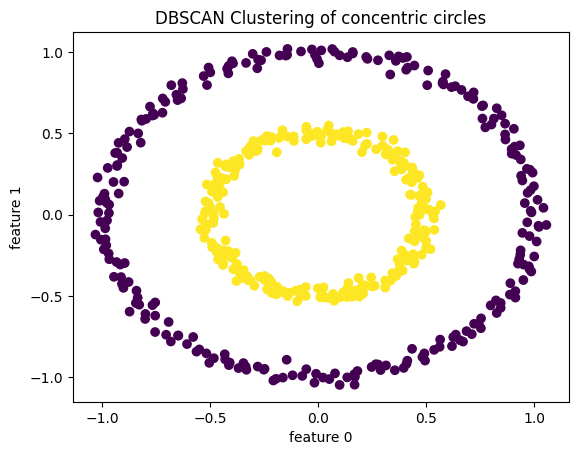

In [13]:
plt.scatter(X[:,0],X[:,1],c=clusters,cmap='viridis',marker='o')
plt.title("DBSCAN Clustering of concentric circles")
plt.xlabel('feature 0')
plt.ylabel('feature 1')
plt.show()

here, we can see that the clusters are made accoring to the density of points

ADVANTAGES OF DBSCAN:

- Robust to outliers
- no need to to specify clusters
- can find arbitrary shaped clusters
- only 2 hyperparameters to tune

LIMITATIONS OF DBSCAN:
- Sensitivity to hyperparameters
- Difficulty with varying density clusters
- Does not predict

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

In [34]:
X,y = make_swiss_roll(n_samples=2700,noise=0.05,random_state=4)

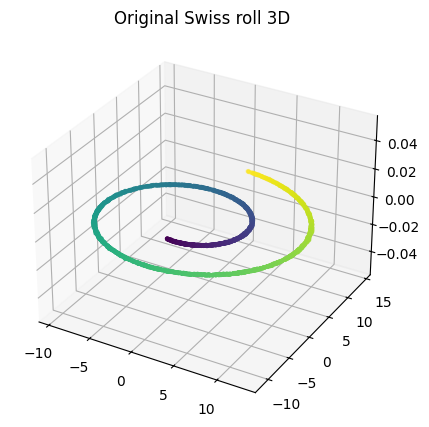

In [35]:
from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(7,5))
ax=fig.add_subplot(111,projection='3d')

ax.scatter(X[:,0],X[:,2],c=y,cmap='viridis',s=5)
ax.set_title("Original Swiss roll 3D")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled= scaler.fit_transform(X)

In [37]:
from sklearn.cluster import DBSCAN

db=DBSCAN(eps=0.2, min_samples=10)

labels=db.fit_predict(X_scaled)
labels

array([ 0, -1,  0, ...,  1, 28, -1], shape=(2700,))

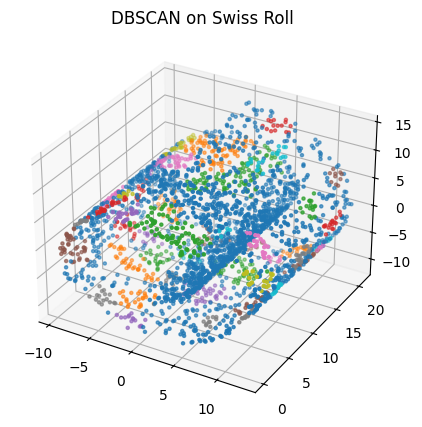

In [38]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=labels,
    cmap='tab10',
    s=5
)

ax.set_title("DBSCAN on Swiss Roll")
plt.show()


DBSCAN partially works on Swiss roll because it relies on local density and neighborhood connectivity, not global geometry.
It can group nearby points along the curved surface, but it fails to truly separate the roll layers because Euclidean distance collapses distant manifold points into close neighbors.